In [3]:
import pandas as pd
df_train = pd.read_csv("/kaggle/input/competitions/playground-series-s4e8/train.csv")
print(df_train.shape)

(3116945, 22)


In [4]:
print(df_train.columns.tolist())
print(df_train.head())
print(df_train.dtypes)
print(df_train['class'].value_counts())
print(df_train['class'].value_counts(normalize=True).round(3) * 100)

['id', 'class', 'cap-diameter', 'cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color', 'stem-height', 'stem-width', 'stem-root', 'stem-surface', 'stem-color', 'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color', 'habitat', 'season']
   id class  cap-diameter cap-shape cap-surface cap-color  \
0   0     e          8.80         f           s         u   
1   1     p          4.51         x           h         o   
2   2     e          6.94         f           s         b   
3   3     e          3.88         f           y         g   
4   4     e          5.85         x           l         w   

  does-bruise-or-bleed gill-attachment gill-spacing gill-color  ...  \
0                    f               a            c          w  ...   
1                    f               a            c          n  ...   
2                    f               x            c          w  ...   
3                    f               

In [5]:
df_train.isna().sum()

id                            0
class                         0
cap-diameter                  4
cap-shape                    40
cap-surface              671023
cap-color                    12
does-bruise-or-bleed          8
gill-attachment          523936
gill-spacing            1258435
gill-color                   57
stem-height                   0
stem-width                    0
stem-root               2757023
stem-surface            1980861
stem-color                   38
veil-type               2957493
veil-color              2740947
has-ring                     24
ring-type                128880
spore-print-color       2849682
habitat                      45
season                        0
dtype: int64

In [6]:
total = len(df_train)
null_pct = (df_train.isnull().sum() / total * 100).round(1)
null_pct = null_pct[null_pct > 0].sort_values(ascending=False)
print(null_pct)

veil-type            94.9
spore-print-color    91.4
stem-root            88.5
veil-color           87.9
stem-surface         63.6
gill-spacing         40.4
cap-surface          21.5
gill-attachment      16.8
ring-type             4.1
dtype: float64


In [ ]:
drop_cols = ['veil-type', 'spore-print-color', 'stem-root',
             'veil-color', 'stem-surface', 'gill-spacing', 'id']

mode_cols = ['cap-surface', 'gill-attachment', 'ring-type',
             'cap-shape', 'cap-color', 'does-bruise-or-bleed',
             'gill-color', 'stem-color', 'has-ring', 'habitat']

median_cols = ['cap-diameter']

df_train = df_train.drop(columns=drop_cols)


for col in mode_cols:
    df_train[col] = df_train[col].fillna(df_train[col].mode()[0])

for col in median_cols:
    df_train[col] = df_train[col].fillna(df_train[col].median())


print("Remaining nulls:", df_train.isnull().sum().sum())
print(df_train.isnull().sum()[df_train.isnull().sum() > 0])
print(f"Shape: {df_train.shape}")

Remaining nulls: 0
Series([], dtype: int64)
Shape: (3116945, 15)


In [8]:
cat_cols = df_train.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns: {cat_cols}\n")
for col in cat_cols:
    print(f"{col:25} {df_train[col].nunique()} — {df_train[col].unique()}")

Categorical columns: ['class', 'cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-color', 'stem-color', 'has-ring', 'ring-type', 'habitat', 'season']

class                     2 — ['e' 'p']
cap-shape                 74 — ['f' 'x' 'p' 'b' 'o' 'c' 's' 'd' 'e' 'n' 'w' 'k' 'l' '19.29' '5 f' 't' 'g'
 'z' 'a' '2.85' '7 x' 'r' 'u' '3.55' 'is s' 'y' '4.22' '3.6' '21.56' 'i'
 '6 x' '24.16' '8' 'm' 'ring-type' '10.13' 'is p' '7.43' 'h' '0.82'
 '10.46' '2.77' '2.94' '12.62' '5.15' '19.04' '4.97' '49.21' 'b f' '9.13'
 '1.66' '3.37' '7.21' '3.25' '11.12' '3 x' '4.3' '7.41' '6.21' '8.29'
 '54.78' '20.25' '3.52' '3.04' '2.63' '3.91' '6.44' '8.3' '7.6' '17.44'
 '4.33' '2.82' '6.53' '19.06']
cap-surface               83 — ['s' 'h' 'y' 'l' 't' 'e' 'g' 'd' 'i' 'w' 'k' '15.94' 'f' 'n' 'r' 'o' 'a'
 'u' 'z' '2.7' 'does l' '5.07' 'p' 'b' 'm' 'cap-diameter' '1.43' 'x'
 '7.14' 'c' 'is h' 'does t' '0.85' '6.57' '12.79' '6.45' '4.66' '23.18'
 '3.06' '16.39' '4.21' 'veil-co

In [ ]:
for col in df_train.select_dtypes(include='object').columns:
    corrupted = df_train[col].str.match(r'^\d', na=False).sum()
    if corrupted > 0:
        print(f"{col:25} corrupted rows: {corrupted}")

cap-shape                 corrupted rows: 51
cap-surface               corrupted rows: 42
cap-color                 corrupted rows: 50
does-bruise-or-bleed      corrupted rows: 3
gill-attachment           corrupted rows: 45
gill-color                corrupted rows: 29
stem-color                corrupted rows: 30
has-ring                  corrupted rows: 1
ring-type                 corrupted rows: 10
habitat                   corrupted rows: 20


In [10]:
cat_cols = df_train.select_dtypes(include='object').columns.tolist()
cat_cols.remove('class')

corrupted_mask = pd.Series(False, index=df_train.index)

for col in cat_cols:
    corrupted_mask |= df_train[col].str.match(r'^\d', na=False)

print(f"Total corrupted rows: {corrupted_mask.sum()}")

df_train = df_train[~corrupted_mask]
print(f"Shape after cleaning: {df_train.shape}")

Total corrupted rows: 281
Shape after cleaning: (3116664, 15)


In [11]:
for col in df_train.select_dtypes(include='object').columns:
    if col != 'class':
        print(f"{col:25} {df_train[col].nunique()} unique values")

cap-shape                 27 unique values
cap-surface               41 unique values
cap-color                 30 unique values
does-bruise-or-bleed      23 unique values
gill-attachment           34 unique values
gill-color                37 unique values
stem-color                29 unique values
has-ring                  22 unique values
ring-type                 30 unique values
habitat                   32 unique values
season                    4 unique values


In [12]:
print(df_train['does-bruise-or-bleed'].value_counts())

does-bruise-or-bleed
f           2569514
t            547044
w                14
c                11
h                 9
b                 7
x                 7
a                 7
y                 7
s                 6
k                 6
e                 4
l                 4
d                 4
p                 4
g                 3
o                 3
z                 3
n                 2
i                 2
has-ring          1
r                 1
u                 1
Name: count, dtype: int64


In [13]:
df_train = df_train[df_train['does-bruise-or-bleed'].isin(['f', 't'])]


for col in ['cap-shape', 'cap-surface', 'cap-color', 'gill-attachment',
            'gill-color', 'stem-color', 'has-ring', 'ring-type', 'habitat', 'season']:
    before = len(df_train)
    df_train = df_train[df_train[col].str.len() == 1]
    dropped = before - len(df_train)
    if dropped > 0:
        print(f"{col}: dropped {dropped} rows")

print(f"\nFinal shape: {df_train.shape}")

cap-shape: dropped 4 rows
cap-surface: dropped 31 rows
cap-color: dropped 22 rows
gill-attachment: dropped 15 rows
gill-color: dropped 38 rows
stem-color: dropped 10 rows
has-ring: dropped 1 rows
ring-type: dropped 17 rows
habitat: dropped 18 rows

Final shape: (3116402, 15)


In [14]:
for col in df_train.select_dtypes(include='object').columns:
    if col != 'class':
        print(f"{col:25} {df_train[col].nunique()} — {sorted(df_train[col].unique())}")

cap-shape                 23 — ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'w', 'x', 'y', 'z']
cap-surface               23 — ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'w', 'x', 'y', 'z']
cap-color                 23 — ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'w', 'x', 'y', 'z']
does-bruise-or-bleed      2 — ['f', 't']
gill-attachment           23 — ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'w', 'x', 'y', 'z']
gill-color                23 — ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'w', 'x', 'y', 'z']
stem-color                23 — ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'w', 'x', 'y', 'z']
has-ring                  21 — ['a', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 

In [ ]:
df_train['class'] = (df_train['class'] == 'p').astype(int) 
df_train['does-bruise-or-bleed'] = (df_train['does-bruise-or-bleed'] == 't').astype(int)

dummy_cols = ['cap-shape', 'cap-surface', 'cap-color', 'gill-attachment',
              'gill-color', 'stem-color', 'has-ring', 'ring-type',
              'habitat', 'season']

df_train = pd.get_dummies(df_train, columns=dummy_cols)

print(f"Shape after encoding: {df_train.shape}")
print(f"Target distribution:\n{df_train['class'].value_counts()}")

Shape after encoding: (3116402, 214)
Target distribution:
class
1    1705119
0    1411283
Name: count, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_train.drop(columns=['class'])
y = df_train['class']

X_temp, X_test, y_temp, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y_temp)

print(f"Train : {X_train.shape} |  {y_train.mean()*100:.1f}%")
print(f"Val   : {X_val.shape}   |  {y_val.mean()*100:.1f}%")
print(f"Test  : {X_test.shape}  |  {y_test.mean()*100:.1f}%")

Train : (1994496, 213) |  54.7%
Val   : (498625, 213)   |  54.7%
Test  : (623281, 213)  |  54.7%


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f"X_train: {X_train_scaled.shape}")
print(f"X_val  : {X_val_scaled.shape}")
print(f"X_test : {X_test_scaled.shape}")

X_train: (1994496, 213)
X_val  : (498625, 213)
X_test : (623281, 213)


In [ ]:
import torch
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train.values)

X_val_tensor   = torch.FloatTensor(X_val_scaled)
y_val_tensor   = torch.FloatTensor(y_val.values)

X_test_tensor  = torch.FloatTensor(X_test_scaled)
y_test_tensor  = torch.FloatTensor(y_test.values)

print(f"X_train: {X_train_tensor.shape} | dtype: {X_train_tensor.dtype}")
print(f"y_train: {y_train_tensor.shape} | dtype: {y_train_tensor.dtype}")
print(f"\nFirst row of X_train: {X_train_tensor[0][:5]}...")  
print(f"First label: {y_train_tensor[0]}")

X_train: torch.Size([1994496, 213]) | dtype: torch.float32
y_train: torch.Size([1994496]) | dtype: torch.float32

First row of X_train: tensor([ 0.2023, -0.4615,  1.5301,  0.2495, -0.0032])...
First label: 1.0


In [19]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor,  y_test_tensor)

batch_size = 1024

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Batch size    : {batch_size}")
print(f"\nEach batch: {batch_size} mushrooms × 213 features")

# Peek at one batch
X_batch, y_batch = next(iter(train_loader))
print(f"\nOne batch X shape: {X_batch.shape}")
print(f"One batch y shape: {y_batch.shape}")

Train batches : 1948
Val batches   : 487
Batch size    : 1024

Each batch: 1024 mushrooms × 213 features

One batch X shape: torch.Size([1024, 213])
One batch y shape: torch.Size([1024])


In [ ]:
import torch.nn as nn
class MushroomNet(nn.Module):
    def __init__(self, input_size):
        super(MushroomNet, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64), 
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = MushroomNet(input_size=213).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

MushroomNet(
  (network): Sequential(
    (0): Linear(in_features=213, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.2, inplace=False)
    (16): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 99,009


In [22]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5,
)

print(f"Criterion : {criterion}")
print(f"Optimizer : {optimizer}")
print(f"Scheduler : ReduceLROnPlateau")

Criterion : BCEWithLogitsLoss()
Optimizer : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Scheduler : ReduceLROnPlateau


In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train() 
    total_loss = 0
    
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        logits = model(X_batch).squeeze()
        
        loss = criterion(logits, y_batch)
        
        optimizer.zero_grad()
       
        loss.backward()
        
        optimizer.step()        
        total_loss += loss.item()
    
    return total_loss / len(loader)  

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()   
          
    total_loss = 0
    all_preds  = []
    all_labels = []
    
    with torch.no_grad():
      
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            logits      = model(X_batch).squeeze()
            loss        = criterion(logits, y_batch)
            
            predictions = torch.sigmoid(logits)

            total_loss += loss.item()
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
           
    
    return total_loss / len(loader), np.array(all_preds), np.array(all_labels)

In [ ]:
import numpy as np

n_epochs      = 50
best_val_loss = float('inf')  
patience      = 5
patience_counter = 0

train_losses = []
val_losses   = []

for epoch in range(n_epochs):
    
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    
    val_loss, val_preds, val_labels = evaluate(model, val_loader, criterion, device)
    
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs} | "
              f"Train: {train_loss:.4f} | "
              f"Val: {val_loss:.4f} | "
              f"Patience: {patience_counter}/{patience}")
    
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

model.load_state_dict(torch.load('best_model.pth'))
print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch   5/50 | Train: 0.0557 | Val: 0.0488 | Patience: 0/5
Epoch  10/50 | Train: 0.0526 | Val: 0.0472 | Patience: 0/5
Epoch  15/50 | Train: 0.0514 | Val: 0.0468 | Patience: 1/5
Epoch  20/50 | Train: 0.0503 | Val: 0.0461 | Patience: 0/5
Epoch  25/50 | Train: 0.0499 | Val: 0.0460 | Patience: 4/5
Epoch  30/50 | Train: 0.0485 | Val: 0.0454 | Patience: 0/5
Epoch  35/50 | Train: 0.0483 | Val: 0.0452 | Patience: 0/5
Epoch  40/50 | Train: 0.0477 | Val: 0.0450 | Patience: 0/5
Epoch  45/50 | Train: 0.0473 | Val: 0.0453 | Patience: 3/5

Early stopping at epoch 47

Best val loss: 0.0450


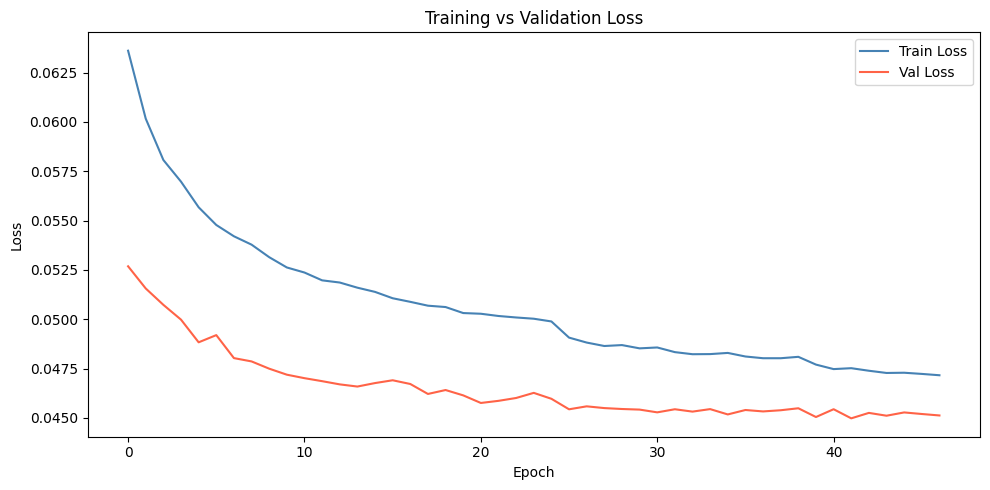

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99    282257
         1.0       0.99      0.99      0.99    341024

    accuracy                           0.99    623281
   macro avg       0.99      0.99      0.99    623281
weighted avg       0.99      0.99      0.99    623281

ROC-AUC : 0.9967
PR-AUC  : 0.9970


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses,   label='Val Loss',   color='tomato')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

test_loss, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

y_pred_binary = (test_preds >= 0.5).astype(int)

from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import precision_recall_curve, auc

print(classification_report(test_labels, y_pred_binary))
print(f"ROC-AUC : {roc_auc_score(test_labels, test_preds):.4f}")

precision, recall, _ = precision_recall_curve(test_labels, test_preds)
print(f"PR-AUC  : {auc(recall, precision):.4f}")